# CH 5 - 6 : POINT ESTIMATES

## Objectif du cahier

Ce notebook transforme le concept d'**estimation ponctuelle** en réflexe opérationnel pour le trading EBTA.

L'idée centrale : après avoir validé qu'une règle semble avoir un edge, il faut répondre à une question plus pratique :

> **Combien puis-je raisonnablement attendre de cette règle dans le futur ?**

La réponse immédiate est souvent un seul chiffre : la **moyenne du backtest**. Mais ce chiffre doit être compris correctement : c'est une **estimation**, pas une promesse.

## 1. L'intuition simple

Imagine une règle de trading qui a produit les rendements quotidiens suivants pendant le backtest :

- jour 1 : +0.20 %
- jour 2 : -0.10 %
- jour 3 : +0.15 %
- jour 4 : +0.05 %

Tu ne connais pas le vrai rendement futur moyen de la règle. Ce vrai rendement est le **paramètre de population**.

Tu n'as qu'un échantillon : ton backtest.

Donc tu prends une statistique de ton échantillon, par exemple la moyenne, et tu dis :

> Mon meilleur chiffre actuel pour approximer le rendement futur moyen est la moyenne observée dans mon backtest.

C'est cela une **estimation ponctuelle**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exemple simple : rendements quotidiens en pourcentage
returns_pct = np.array([0.20, -0.10, 0.15, 0.05])

point_estimate = returns_pct.mean()
point_estimate

np.float64(0.075)

La valeur obtenue est une **estimation ponctuelle** : un seul chiffre censé approximer un paramètre inconnu.

Dans ce cas, elle représente notre meilleure approximation du rendement quotidien moyen futur.

In [2]:
print(f"Estimation ponctuelle du rendement quotidien moyen : {point_estimate:.3f}%")

Estimation ponctuelle du rendement quotidien moyen : 0.075%


## 2. Traduction EBTA

Dans le protocole EBTA :

- le **paramètre de population** = la vraie performance future de la règle ;
- l'**échantillon** = les données du backtest ;
- la **statistique d'échantillon** = le chiffre calculé sur le backtest ;
- l'**estimation ponctuelle** = ce chiffre utilisé comme approximation du futur.

En pratique, l'estimateur principal est souvent :

$$
\hat{\mu} = \bar{r}
$$

Où :

- $\hat{\mu}$ = estimation du rendement moyen futur ;
- $\bar{r}$ = moyenne des rendements observés dans le backtest.

In [3]:
# Créons un faux backtest de 252 jours
np.random.seed(42)

n_days = 252
true_daily_mean = 0.04 / 100   # 0.04% par jour
true_daily_vol = 0.80 / 100    # 0.80% de volatilité quotidienne

backtest_returns = np.random.normal(
    loc=true_daily_mean,
    scale=true_daily_vol,
    size=n_days
)

estimated_daily_mean = backtest_returns.mean()
estimated_annual_return = estimated_daily_mean * 252

print(f"Moyenne quotidienne estimée : {estimated_daily_mean*100:.4f}%")
print(f"Rendement annualisé estimé : {estimated_annual_return*100:.2f}%")

Moyenne quotidienne estimée : 0.0370%
Rendement annualisé estimé : 9.32%


## 3. Le piège mental : ce chiffre n'est pas la vérité

Voilà le point crucial.

Quand ton backtest affiche par exemple **+10 % annualisé**, ton cerveau veut lire :

> Cette stratégie fera 10 % dans le futur.

Mais la lecture scientifique est :

> Sur cet échantillon précis, la meilleure estimation ponctuelle de la performance future est 10 %.

Ce n'est pas pareil.

La différence vient de l'**erreur d'échantillonnage** : un autre échantillon historique aurait pu donner 6 %, 12 %, -2 %, etc.

In [4]:
# Simulons plusieurs backtests possibles d'une même stratégie
np.random.seed(7)

n_simulations = 5000
sample_size = 252

estimated_means = []

for _ in range(n_simulations):
    sample = np.random.normal(
        loc=true_daily_mean,
        scale=true_daily_vol,
        size=sample_size
    )
    estimated_means.append(sample.mean() * 252 * 100)  # annualisé en %

estimated_means = np.array(estimated_means)

print(f"Vraie performance annualisée utilisée dans la simulation : {true_daily_mean*252*100:.2f}%")
print(f"Moyenne des estimations ponctuelles : {estimated_means.mean():.2f}%")
print(f"Écart-type des estimations ponctuelles : {estimated_means.std():.2f}%")

Vraie performance annualisée utilisée dans la simulation : 10.08%
Moyenne des estimations ponctuelles : 10.10%
Écart-type des estimations ponctuelles : 12.79%


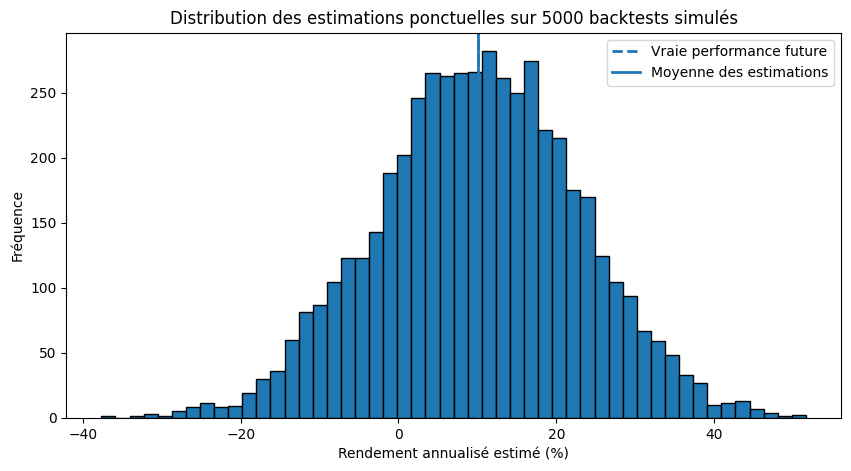

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(estimated_means, bins=50, edgecolor='black')
plt.axvline(true_daily_mean * 252 * 100, linestyle='--', linewidth=2, label='Vraie performance future')
plt.axvline(estimated_means.mean(), linestyle='-', linewidth=2, label='Moyenne des estimations')
plt.title("Distribution des estimations ponctuelles sur 5000 backtests simulés")
plt.xlabel("Rendement annualisé estimé (%)")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 4. EUREKA : l'estimation ponctuelle est une flèche, pas une zone

L'image mentale importante :

- l'estimation ponctuelle te donne **une flèche** ;
- l'intervalle de confiance te donne **une zone probable**.

La flèche est utile pour viser.

Mais si tu ignores la largeur de la zone autour de la flèche, tu peux surestimer la précision de ton edge.

Donc une estimation ponctuelle est nécessaire, mais incomplète.

## 5. Pourquoi la moyenne est privilégiée ?

Aronson met en avant quatre propriétés d'un bon estimateur.

### 1. Sans biais

Sur beaucoup d'échantillons, les erreurs positives et négatives tendent à s'annuler.

La moyenne ne promet pas d'être juste à chaque backtest, mais elle est juste **en moyenne**.

### 2. Consistante

Plus la taille de l'échantillon augmente, plus la moyenne estimée se rapproche de la vraie moyenne.

En trading : plus tu as de trades ou de jours pertinents, plus ton estimation devient stable.

### 3. Efficiente

Entre plusieurs estimateurs possibles, la moyenne a souvent une erreur standard plus faible.

Elle produit donc des estimations plus resserrées que d'autres mesures comme la médiane, dans beaucoup de contextes classiques.

### 4. Suffisante

Elle exploite l'information utile disponible dans les observations pour estimer la moyenne de population.

## 6. Démonstration : plus N augmente, plus l'estimation se stabilise

Ici, on simule plusieurs tailles de backtest.

On va observer que plus le nombre de jours augmente, plus les estimations ponctuelles se resserrent autour de la vraie performance.

In [6]:
np.random.seed(123)

sample_sizes = [50, 100, 252, 500, 1000, 2500]
results = []

for n in sample_sizes:
    estimates = []
    for _ in range(3000):
        sample = np.random.normal(true_daily_mean, true_daily_vol, n)
        estimates.append(sample.mean() * 252 * 100)
    estimates = np.array(estimates)
    results.append({
        "N jours": n,
        "Moyenne des estimations annualisées (%)": estimates.mean(),
        "Erreur standard empirique (%)": estimates.std(),
        "5e percentile (%)": np.percentile(estimates, 5),
        "95e percentile (%)": np.percentile(estimates, 95),
    })

pd.DataFrame(results)

,N jours,Moyenne des estimations annualisées (%),Erreur standard empirique (%),5e percentile (%),95e percentile (%)
0,50,10.353157,28.288307,-35.528061,57.049237
1,100,10.328845,20.693480,-23.202265,44.371015
2,252,10.075669,12.907659,-11.269039,31.129083
3,500,10.044728,9.068970,-4.649752,25.151805
4,1000,10.252388,6.483204,-0.456505,20.795157
5,2500,10.077807,4.072805,3.628187,16.932501


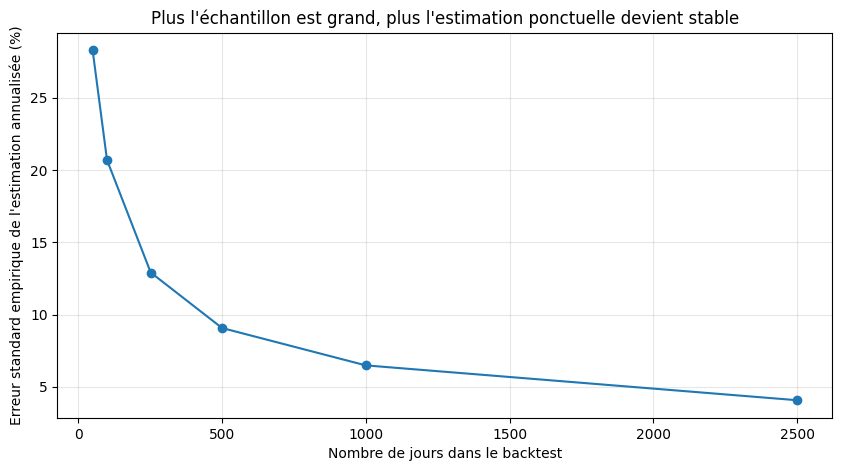

In [7]:
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(df_results["N jours"], df_results["Erreur standard empirique (%)"], marker='o')
plt.title("Plus l'échantillon est grand, plus l'estimation ponctuelle devient stable")
plt.xlabel("Nombre de jours dans le backtest")
plt.ylabel("Erreur standard empirique de l'estimation annualisée (%)")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Exemple trading complet

On va maintenant construire un mini-backtest fictif.

La règle produit des rendements quotidiens. On calcule :

- la moyenne quotidienne ;
- l'estimation annualisée ;
- la volatilité ;
- l'erreur standard ;
- une première lecture du niveau d'incertitude.

Même si le chapitre parle surtout de l'estimation ponctuelle, on ajoute l'erreur standard pour montrer pourquoi le chiffre seul ne suffit pas.

In [8]:
np.random.seed(99)

# Mini backtest fictif d'une règle
n = 400
strategy_returns = np.random.normal(loc=0.035/100, scale=0.70/100, size=n)

mean_daily = strategy_returns.mean()
vol_daily = strategy_returns.std(ddof=1)
standard_error_daily = vol_daily / np.sqrt(n)

point_estimate_annual = mean_daily * 252
standard_error_annual = standard_error_daily * 252

summary = pd.DataFrame({
    "Mesure": [
        "Nombre d'observations",
        "Moyenne quotidienne estimée",
        "Volatilité quotidienne",
        "Erreur standard quotidienne",
        "Estimation ponctuelle annualisée",
        "Erreur standard annualisée approximative",
    ],
    "Valeur": [
        n,
        f"{mean_daily*100:.4f}%",
        f"{vol_daily*100:.4f}%",
        f"{standard_error_daily*100:.4f}%",
        f"{point_estimate_annual*100:.2f}%",
        f"{standard_error_annual*100:.2f}%",
    ]
})

summary

,Mesure,Valeur
0,Nombre d'observations,400
1,Moyenne quotidienne estimée,0.0719%
2,Volatilité quotidienne,0.6935%
3,Erreur standard quotidienne,0.0347%
4,Estimation ponctuelle annualisée,18.11%
5,Erreur standard annualisée approximative,8.74%


## 8. Lecture opérationnelle

Supposons que le tableau affiche une estimation annualisée proche de **9 %**.

La mauvaise lecture serait :

> Je vais faire 9 %.

La bonne lecture EBTA serait :

> Le meilleur estimateur ponctuel actuel donne environ 9 % annualisé, mais je dois encore mesurer l'incertitude autour de ce chiffre.

Donc le chiffre sert d'**ancrage rationnel**, pas de certitude.

## 9. Différence entre test d'hypothèse et estimation ponctuelle

| Question | Outil | Réponse |
|---|---|---|
| Est-ce que la règle semble avoir un edge ? | Test d'hypothèse | Oui / Non, selon la p-value ou le seuil critique |
| Combien pourrait-elle rapporter ? | Estimation ponctuelle | Un chiffre, par exemple +10 % annualisé |
| Quelle est la marge d'erreur ? | Intervalle de confiance | Une fourchette, par exemple +2 % à +18 % |

Le test d'hypothèse est une **décision**.

L'estimation ponctuelle est une **prévision chiffrée**.

L'intervalle de confiance est une **prévision avec incertitude**.

## 10. Fonction Python réutilisable

Voici une fonction simple que tu peux réutiliser sur une série de rendements quotidiens.

In [9]:
def point_estimate_report(returns, periods_per_year=252):
    """
    Calcule un rapport simple d'estimation ponctuelle pour une stratégie.
    
    Parameters
    ----------
    returns : array-like
        Rendements périodiques de la stratégie, en décimal.
        Exemple : 0.001 = +0.10%.
    periods_per_year : int
        Nombre de périodes par an. 252 pour des rendements quotidiens de marché.
    """
    returns = np.asarray(returns)
    n = len(returns)
    mean_periodic = returns.mean()
    vol_periodic = returns.std(ddof=1)
    se_periodic = vol_periodic / np.sqrt(n)
    
    return pd.DataFrame({
        "Mesure": [
            "N",
            "Estimation ponctuelle périodique",
            "Estimation ponctuelle annualisée",
            "Volatilité périodique",
            "Erreur standard périodique",
            "Erreur standard annualisée approximative",
        ],
        "Valeur": [
            n,
            f"{mean_periodic*100:.4f}%",
            f"{mean_periodic*periods_per_year*100:.2f}%",
            f"{vol_periodic*100:.4f}%",
            f"{se_periodic*100:.4f}%",
            f"{se_periodic*periods_per_year*100:.2f}%",
        ]
    })

point_estimate_report(strategy_returns)

,Mesure,Valeur
0,N,400
1,Estimation ponctuelle périodique,0.0719%
2,Estimation ponctuelle annualisée,18.11%
3,Volatilité périodique,0.6935%
4,Erreur standard périodique,0.0347%
5,Erreur standard annualisée approximative,8.74%


## 11. Mini-exercice

Modifie les paramètres ci-dessous :

- `true_daily_mean`
- `true_daily_vol`
- `sample_size`

Puis observe comment l'estimation ponctuelle peut changer d'un backtest à l'autre.

L'objectif n'est pas seulement de lire le résultat, mais de sentir ceci :

> Plus le marché est volatile et plus l'échantillon est petit, plus l'estimation ponctuelle est fragile.

In [10]:
# À modifier pour t'entraîner
np.random.seed(2026)

true_daily_mean_exercise = 0.04 / 100
true_daily_vol_exercise = 0.90 / 100
sample_size_exercise = 150

sample = np.random.normal(
    loc=true_daily_mean_exercise,
    scale=true_daily_vol_exercise,
    size=sample_size_exercise
)

point_estimate_report(sample)

,Mesure,Valeur
0,N,150
1,Estimation ponctuelle périodique,0.1194%
2,Estimation ponctuelle annualisée,30.09%
3,Volatilité périodique,0.8653%
4,Erreur standard périodique,0.0707%
5,Erreur standard annualisée approximative,17.80%


## 12. À retenir absolument

1. Une **estimation ponctuelle** est un seul chiffre utilisé pour approximer un paramètre inconnu.
2. En trading EBTA, la moyenne du backtest peut servir d'estimation ponctuelle du rendement futur.
3. Ce chiffre est une **devinette scientifique**, pas une certitude.
4. La moyenne est privilégiée car elle est sans biais, consistante, efficiente et suffisante dans le cadre classique présenté.
5. Plus le nombre d'observations augmente, plus l'estimation devient stable.
6. Une estimation ponctuelle doit ensuite être complétée par un **intervalle de confiance**.

Phrase à garder :

> Le point estimate me donne la cible. L'intervalle de confiance me dit à quel point ma cible est floue.

---

# Annexe — Source originale collée

### **CH 5 - 6 : POINT ESTIMATES**

Voici l’analyse technique des estimations ponctuelles, la méthode permettant de transformer un résultat de backtest en une prévision chiffrée de la performance future d'une règle de trading.

#### **Idées clés :**
*   **Approximation du futur :** Une estimation ponctuelle est une valeur unique calculée sur un échantillon pour deviner la valeur d'un paramètre de population inconnu, comme le rendement futur.
*   **La moyenne comme standard :** En trading EBTA, la moyenne des rendements du backtest est l'estimation ponctuelle privilégiée pour projeter l'espérance de gain.
*   **Critères de scientificité :** Un bon estimateur doit répondre à quatre critères mathématiques : absence de biais, convergence (consistance), efficience et suffisance.
*   **Information limitée :** Bien qu'utile, une estimation ponctuelle est incomplète car elle ne quantifie pas l'incertitude liée à l'erreur d'échantillonnage.

#### **Référence :**
*Point Estimates* (Pages 243–245 ; Audiobook 142, 145).

#### **Citation Directe :**
« A point estimate is a single value that approximates the population parameter, for example the rule has an expected return of 10 percent. » (Page 243).

#### **Vision Macro :**
L'enjeu est de passer de la simple validation (le test d'hypothèse) à la planification opérationnelle. Le test d'hypothèse répond à la question « Est-ce que ça marche ? », tandis que l'estimation ponctuelle répond à « Combien cela va-t-il rapporter ? ». C'est l'outil qui permet au trader de définir ses objectifs de profit et de calibrer la gestion de son risque sur une base rationnelle plutôt qu'intuitive.

#### **Vision Micro :**
Le mécanisme de l'estimation ponctuelle repose sur l'utilisation d'une statistique d'échantillon comme substitut au paramètre réel. 

1.  **Exemples d'estimateurs :** Les plus courants sont la moyenne, la médiane, l'écart-type et la variance. 
2.  **La supériorité de la moyenne d'échantillon :** Aronson démontre qu'elle est mathématiquement le "meilleur" estimateur car elle remplit les quatre conditions de qualité :
    *   **Unbiased (Sans biais) :** Ses erreurs s'annulent en moyenne sur le long terme. Les déviations entre la moyenne de l'échantillon et celle de la population sont nulles en moyenne.
    *   **Consistent (Convergent/Consistant) :** Sa précision augmente mécaniquement avec la taille de l'échantillon ($N$). Plus il y a de trades, plus l'estimation se rapproche de la vérité.
    *   **Efficient (Efficient) :** Elle produit la distribution d'échantillonnage la plus étroite possible, minimisant l'erreur standard.
    *   **Sufficient (Suffisant) :** Elle utilise toute l'information disponible dans les données sans en gaspiller.

#### **Résumé Simplifié :**
L'estimation ponctuelle, c'est comme regarder votre moyenne de points après 10 matchs de basket et dire : « Je marquerai probablement ce même nombre de points au prochain match ». C'est votre meilleure "devinette" scientifique basée sur votre passé.

#### **Exemples du livre pour mieux comprendre :**
*   **L'estimation à 10 % :** Si votre backtest affiche un profit moyen annualisé de 10 %, ce chiffre est votre estimation ponctuelle de ce que la règle rapportera dans le "futur pratique immédiat".
*   **La comparaison moyenne vs médiane :** Aronson précise que pour de grands échantillons, l'erreur standard de la moyenne est environ 80 % plus petite que celle de la médiane, rendant la moyenne beaucoup plus "efficiente" pour prévoir les gains.

#### **Actions Concrètes :**
*   **Utiliser la moyenne comme ancrage :** Calculez la moyenne arithmétique de vos rendements quotidiens detrendés pour obtenir votre espérance de gain future la plus probable.
*   **Maximiser le nombre de données :** Pour que votre estimation soit "consistante", cherchez à avoir le plus grand historique de trades possible afin de réduire l'écart avec la réalité future.
*   **Ne jamais s'arrêter à un chiffre :** Une estimation de 10 % n'a de valeur que si elle est complétée par un intervalle de confiance pour connaître la marge d'erreur.

#### **À retenir absolument :**
*   **Point Estimate** = Un seul chiffre de performance attendue.
*   La **moyenne d'échantillon** est l'estimateur le plus fiable en trading objectif.
*   Elle doit être calculée sur des données **detrendées** pour être valide.
*   Plus le nombre de trades ($N$) est élevé, plus l'estimation est **consistante**.
*   C'est une estimation du **futur**, pas seulement un constat du passé.

J'ai terminé l'analyse des estimations ponctuelles selon le protocole EBTA.